In [ ]:
# import pymysql
# conn = pymysql.connect(host="localhost", user="root", password="비밀번호", database="factory_db")
# cur = conn.cursor()
# cur.execute("SELECT COUNT(*) FROM raw_power_data")
# print(cur.fetchone())
# conn.close()

(33696013,)


In [ ]:
"""
설비간 activePower 상관관계 분석
================================
목적: 13개 설비의 activePower가 서로 얼마나 비슷한지 확인.
      상관계수가 대부분 0.95+ 로 나오면 -> 동일/복제 신호 가능성 높음.
 
방법: 설비별로 (ts, activePower)만 가져와서 ts 기준으로 피벗 후 상관행렬 계산.
      SELECT는 idx_module 인덱스를 타서 빠르게 필터링됨.
"""
 
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from dotenv import load_dotenv

load_dotenv()  # .env 파일 읽어서 환경변수로 등록

import matplotlib as mpl

mpl.rcParams['font.family'] = 'Nanum Gothic'
mpl.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

In [ ]:
# =========================================================
# 설정
# =========================================================
DB_CONFIG = dict(
    host=os.environ["DB_HOST"],
    user=os.environ["DB_USER"],
    password=os.environ["DB_PASSWORD"],
    database=os.environ["DB_NAME"],
)
TABLE_NAME = "raw_power_data"
 
conn = pymysql.connect(**DB_CONFIG)

In [4]:
# =========================================================
# STEP 1. 설비 목록 가져오기
# =========================================================
modules = pd.read_sql(f"SELECT DISTINCT module FROM {TABLE_NAME} ORDER BY module", conn)["module"].tolist()
print(f"설비 {len(modules)}개 확인:", modules)

설비 13개 확인: ['1(PM-3)', '11(우측분전반1)', '12(4호기)', '13(3호기)', '14(2호기)', '15(예비건조기)', '16(호이스트)', '17(6호기)', '18(우측분전반2)', '2(L-1전등)', '3(분쇄기(2))', '4(분쇄기(1))', '5(좌측분전반)']


/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_6763/483791362.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  modules = pd.read_sql(f"SELECT DISTINCT module FROM {TABLE_NAME} ORDER BY module", conn)["module"].tolist()


In [5]:
# =========================================================
# STEP 2. 설비별로 (ts, activePower)만 가져와서 wide format으로 합치기
#   -> 전체 컬럼 다 가져오면 무겁기 때문에 필요한 2개 컬럼만 조회
# =========================================================
merged = None
for i, m in enumerate(modules):
    print(f"[{i+1}/{len(modules)}] {m} 조회 중...")
    df = pd.read_sql(
        f"SELECT ts, activePower FROM {TABLE_NAME} WHERE module = %s ORDER BY ts",
        conn, params=(m,)
    )
    df = df.rename(columns={"activePower": m}).set_index("ts")
    merged = df if merged is None else merged.join(df, how="outer")
 
conn.close()
print("\n전체 shape:", merged.shape)

[1/13] 1(PM-3) 조회 중...


/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_6763/2572638718.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


[2/13] 11(우측분전반1) 조회 중...
[3/13] 12(4호기) 조회 중...
[4/13] 13(3호기) 조회 중...
[5/13] 14(2호기) 조회 중...
[6/13] 15(예비건조기) 조회 중...
[7/13] 16(호이스트) 조회 중...
[8/13] 17(6호기) 조회 중...
[9/13] 18(우측분전반2) 조회 중...
[10/13] 2(L-1전등) 조회 중...
[11/13] 3(분쇄기(2)) 조회 중...
[12/13] 4(분쇄기(1)) 조회 중...
[13/13] 5(좌측분전반) 조회 중...

전체 shape: (8488801, 13)


In [ ]:
# =========================================================
# STEP 3. 상관행렬 계산
# =========================================================
corr_matrix = merged.corr()
print("\n=== 상관행렬 ===")
print(corr_matrix.round(3))
 
corr_matrix.to_csv("module_correlation_matrix.csv")


=== 상관행렬 ===
            1(PM-3)  11(우측분전반1)  12(4호기)  13(3호기)  14(2호기)  15(예비건조기)  \
1(PM-3)       1.000       0.024   -0.002   -0.003    0.013      0.021   
11(우측분전반1)    0.024       1.000    0.003   -0.025   -0.015      0.020   
12(4호기)      -0.002       0.003    1.000   -0.007   -0.009      0.002   
13(3호기)      -0.003      -0.025   -0.007    1.000    0.003     -0.012   
14(2호기)       0.013      -0.015   -0.009    0.003    1.000     -0.021   
15(예비건조기)     0.021       0.020    0.002   -0.012   -0.021      1.000   
16(호이스트)      0.003       0.008    0.009    0.017    0.016     -0.015   
17(6호기)       0.013       0.001    0.001   -0.027    0.014     -0.019   
18(우측분전반2)    0.003       0.002   -0.002   -0.027    0.015     -0.000   
2(L-1전등)      0.024      -0.017    0.005    0.032   -0.002     -0.012   
3(분쇄기(2))     0.015       0.007   -0.011    0.013    0.001     -0.008   
4(분쇄기(1))    -0.008      -0.003   -0.010    0.034   -0.005     -0.017   
5(좌측분전반)     -0.026      -0.037   -0.

In [ ]:
# =========================================================
# STEP 4. 대각선 제외하고 가장 높은 상관관계 쌍들 확인
# =========================================================
corr_pairs = (
    corr_matrix.where(~corr_matrix.isna())
    .stack()
    .reset_index()
)
corr_pairs.columns = ["module_a", "module_b", "corr"]
corr_pairs = corr_pairs[corr_pairs["module_a"] < corr_pairs["module_b"]]  # 중복/대각선 제거
corr_pairs = corr_pairs.sort_values("corr", ascending=False)
 
print("\n=== 상관관계 높은 순 상위 20쌍 ===")
print(corr_pairs.head(20).to_string(index=False))
 
print(f"\n상관계수 0.95 이상 쌍 개수: {(corr_pairs['corr'] >= 0.95).sum()} / 전체 {len(corr_pairs)}쌍")
print(f"상관계수 0.99 이상 쌍 개수: {(corr_pairs['corr'] >= 0.99).sum()} / 전체 {len(corr_pairs)}쌍")
 
corr_pairs.to_csv("module_correlation_pairs.csv", index=False)


=== 상관관계 높은 순 상위 20쌍 ===
  module_a   module_b     corr
   13(3호기)  4(분쇄기(1)) 0.033937
   13(3호기)   2(L-1전등) 0.032135
 3(분쇄기(2))   5(좌측분전반) 0.032108
   1(PM-3)   2(L-1전등) 0.024324
   1(PM-3) 11(우측분전반1) 0.023895
   1(PM-3)  15(예비건조기) 0.021224
11(우측분전반1)  15(예비건조기) 0.020391
   13(3호기)   5(좌측분전반) 0.016902
   13(3호기)   16(호이스트) 0.016878
   14(2호기)   16(호이스트) 0.016007
   14(2호기) 18(우측분전반2) 0.014737
  2(L-1전등)  3(분쇄기(2)) 0.014726
   1(PM-3)  3(분쇄기(2)) 0.014623
   14(2호기)    17(6호기) 0.013555
   1(PM-3)    17(6호기) 0.013254
   1(PM-3)    14(2호기) 0.013204
   13(3호기)  3(분쇄기(2)) 0.012844
   17(6호기)   5(좌측분전반) 0.009327
   12(4호기)   16(호이스트) 0.008881
11(우측분전반1)   16(호이스트) 0.007896

상관계수 0.95 이상 쌍 개수: 0 / 전체 78쌍
상관계수 0.99 이상 쌍 개수: 0 / 전체 78쌍


Matplotlib is building the font cache; this may take a moment.



히트맵 저장 완료: module_correlation_heatmap.png


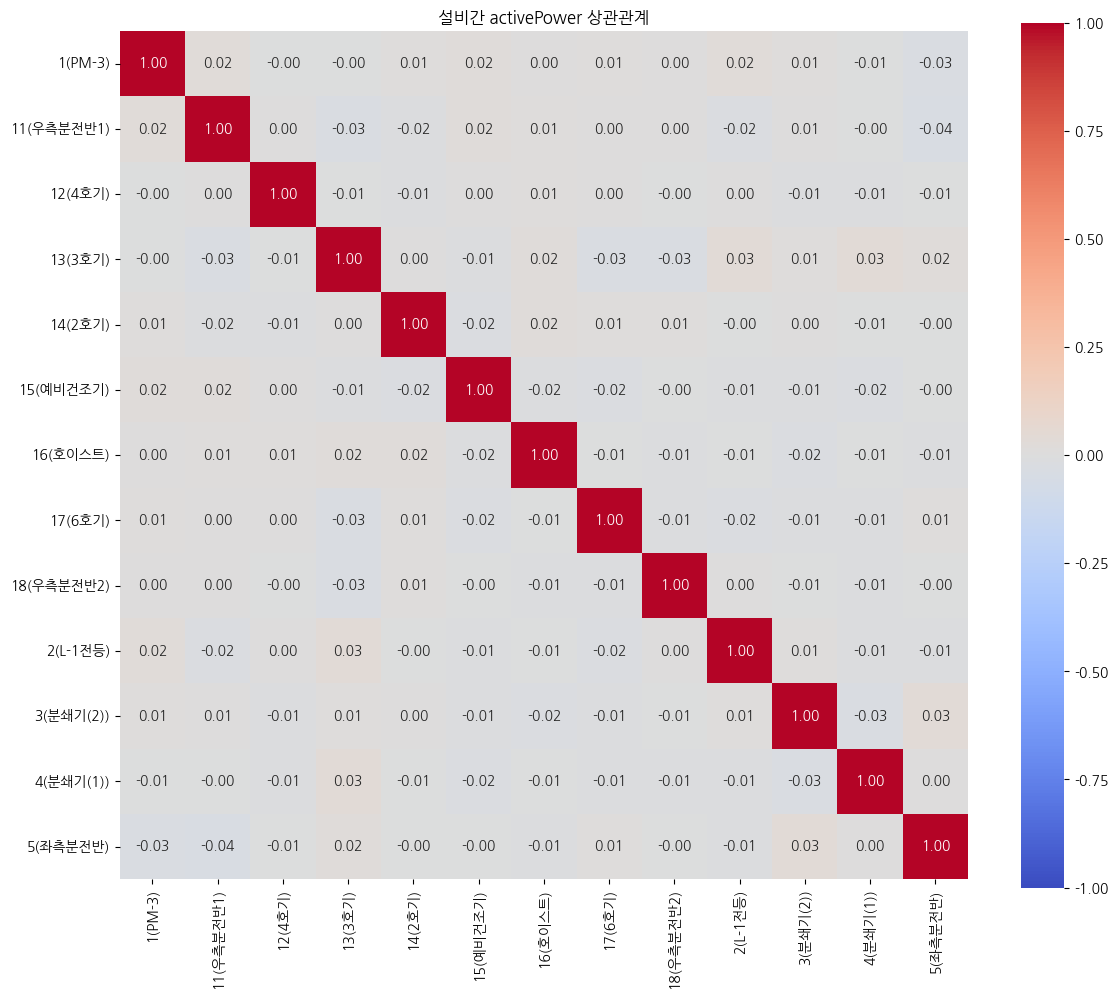

In [ ]:
# =========================================================
# STEP 5. 히트맵 시각화
# =========================================================
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("설비간 activePower 상관관계")
plt.tight_layout()
plt.savefig("module_correlation_heatmap.png", dpi=150)
print("\n히트맵 저장 완료: module_correlation_heatmap.png")
 

In [ ]:
"""
물리적 정합성 검증: activePower 적분 vs accumActiveEnergy 실측 증가량
====================================================================
실제 센서 데이터라면: activePower(순간전력)를 시간으로 적분한 값이
accumActiveEnergy(누적 전력량)의 증가량과 거의 일치해야 함.

만약 안 맞으면 -> 두 컬럼이 서로 무관하게 독립적으로 생성된 합성값일 가능성 높음.
"""

import pymysql
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()  # .env 파일 읽어서 환경변수로 등록

DB_CONFIG = dict(
    host=os.environ["DB_HOST"],
    user=os.environ["DB_USER"],
    password=os.environ["DB_PASSWORD"],
    database=os.environ["DB_NAME"],
)
TABLE_NAME = "raw_power_data"

conn = pymysql.connect(**DB_CONFIG)

# 설비 하나만 골라서 검증 (예: 분쇄기(1))
MODULE = "4(분쇄기(1))"

df = pd.read_sql(
    f"SELECT ts, activePower, accumActiveEnergy FROM {TABLE_NAME} "
    f"WHERE module = %s ORDER BY ts LIMIT 100000",
    conn, params=(MODULE,)
)
conn.close()

# ts가 ms 단위 epoch라고 가정 -> 초 단위 시간 간격 계산
df["dt_sec"] = df["ts"].diff() / 1000
df["dt_sec"] = df["dt_sec"].fillna(df["dt_sec"].median())

# activePower(kW로 가정) x 시간(h) 적분 -> kWh
df["energy_step_kwh"] = df["activePower"] * (df["dt_sec"] / 3600)
integrated_energy = df["energy_step_kwh"].sum()

# accumActiveEnergy 실측 증가량
actual_energy_delta = df["accumActiveEnergy"].iloc[-1] - df["accumActiveEnergy"].iloc[0]

print(f"[{MODULE}] 검증 결과 (샘플 {len(df)}행)")
print(f"  activePower 적분값        : {integrated_energy:,.2f}")
print(f"  accumActiveEnergy 실측증가: {actual_energy_delta:,.2f}")
print(f"  비율 (적분값/실측증가)     : {integrated_energy / actual_energy_delta if actual_energy_delta != 0 else 'N/A'}")
print()
print("  -> 비율이 1에 가까우면 실제 물리 데이터일 가능성 높음")
print("  -> 비율이 터무니없이 크거나 작으면 (10배, 100배 차이 등) 두 컬럼이 서로 무관하게 생성됐을 가능성")

# 추가: activePower 분포 형태 확인 (정규분포처럼 매끈한지, 아니면 실제 가동패턴처럼 구간별인지)
print("\n[activePower 분포 요약]")
print(df["activePower"].describe())
print("\n[0 근처 값 비율] (설비가 꺼져있을 때 0에 가까워야 정상)")
print(f"  activePower < 100인 비율: {(df['activePower'] < 100).mean()*100:.2f}%")

/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_6763/3867517829.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


[4(분쇄기(1))] 검증 결과 (샘플 100000행)
  activePower 적분값        : 418,042.20
  accumActiveEnergy 실측증가: 418,039.00
  비율 (적분값/실측증가)     : 1.0000076488411103

  -> 비율이 1에 가까우면 실제 물리 데이터일 가능성 높음
  -> 비율이 터무니없이 크거나 작으면 (10배, 100배 차이 등) 두 컬럼이 서로 무관하게 생성됐을 가능성

[activePower 분포 요약]
count    100000.000000
mean       3009.903822
std         717.893652
min         940.020000
25%        2501.010000
50%        3010.195000
75%        3519.672500
max        5083.760000
Name: activePower, dtype: float64

[0 근처 값 비율] (설비가 꺼져있을 때 0에 가까워야 정상)
  activePower < 100인 비율: 0.00%


/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_6763/26242196.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


저장 완료: timeseries_pattern_check.png

operation 컬럼 고유값: [1]

operation별 activePower 평균:
                  mean     min      max  count
operation                                     
1          3015.502585  949.05  5077.71  20000


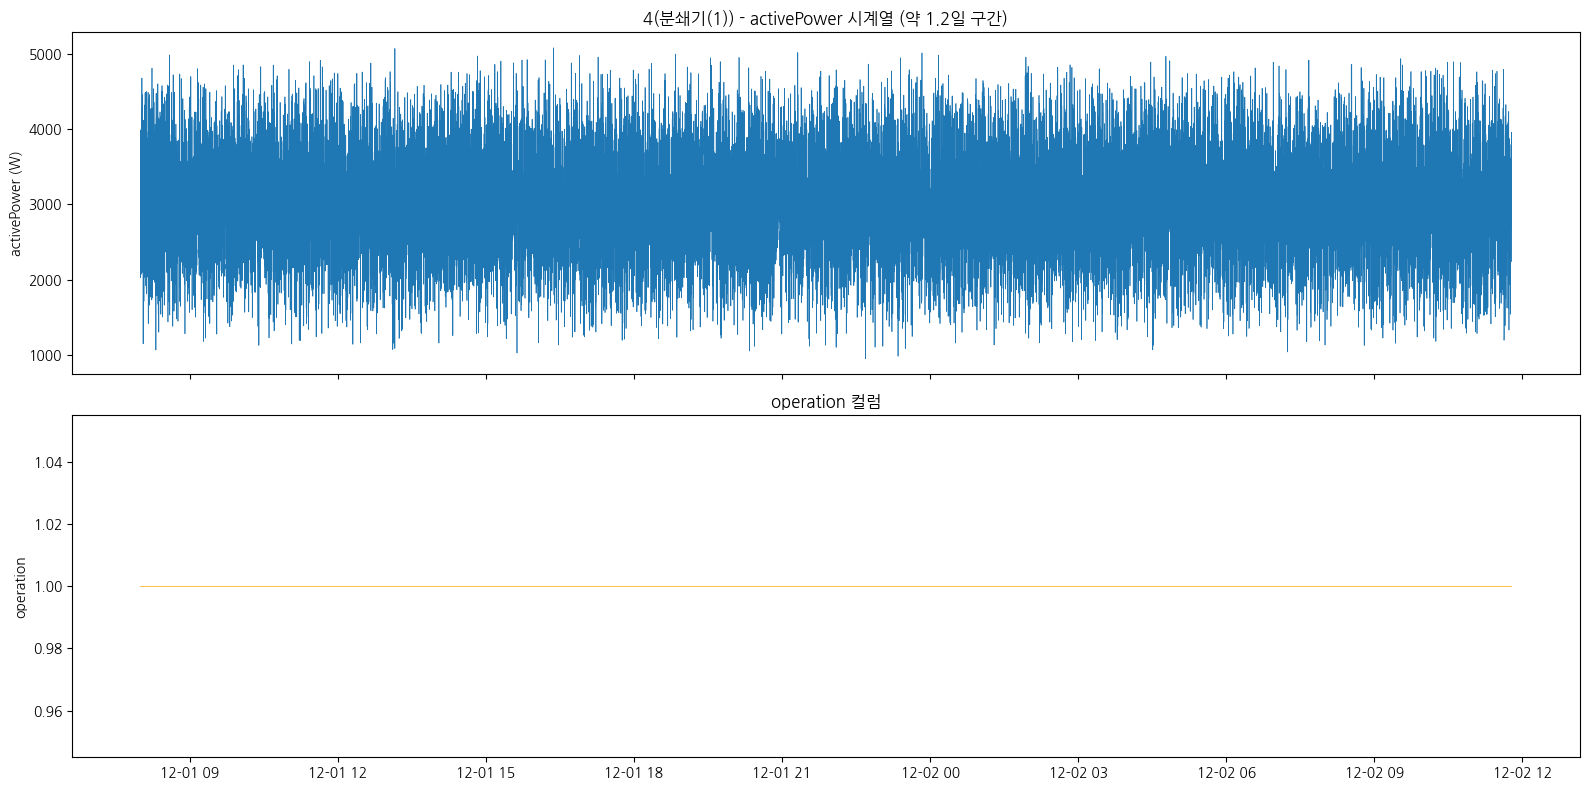

In [ ]:
"""
activePower 시계열 패턴 확인 + operation 컬럼과의 관계 확인
"""

import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Nanum Gothic'
mpl.rcParams['axes.unicode_minus'] = False

import os
from dotenv import load_dotenv

load_dotenv()  # .env 파일 읽어서 환경변수로 등록

DB_CONFIG = dict(
    host=os.environ["DB_HOST"],
    user=os.environ["DB_USER"],
    password=os.environ["DB_PASSWORD"],
    database=os.environ["DB_NAME"],
)
TABLE_NAME = "raw_power_data"
MODULE = "4(분쇄기(1))"

conn = pymysql.connect(**DB_CONFIG)
df = pd.read_sql(
    f"SELECT ts, activePower, operation FROM {TABLE_NAME} "
    f"WHERE module = %s ORDER BY ts LIMIT 20000",  # 5초 간격이면 약 1.2일 분량
    conn, params=(MODULE,)
)
conn.close()

df["datetime"] = pd.to_datetime(df["ts"], unit="ms")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df["datetime"], df["activePower"], linewidth=0.5)
axes[0].set_title(f"{MODULE} - activePower 시계열 (약 1.2일 구간)")
axes[0].set_ylabel("activePower (W)")

axes[1].plot(df["datetime"], df["operation"], linewidth=0.5, color="orange")
axes[1].set_title("operation 컬럼")
axes[1].set_ylabel("operation")

plt.tight_layout()
plt.savefig("timeseries_pattern_check.png", dpi=150)
print("저장 완료: timeseries_pattern_check.png")

# operation 값 종류 및 activePower와의 관계
print("\noperation 컬럼 고유값:", df["operation"].unique())
print("\noperation별 activePower 평균:")
print(df.groupby("operation")["activePower"].agg(["mean", "min", "max", "count"]))

In [ ]:
"""
전체 33,696,013행 기준 컬럼별 통계 추출
========================================
SQL 집계 함수(AVG/STDDEV/MIN/MAX)를 사용해서 전체 데이터를 파이썬 메모리에
올리지 않고 MySQL 서버에서 직접 계산 -> 빠르고 안전함
"""

import pymysql
import pandas as pd

import os
from dotenv import load_dotenv

load_dotenv()  # .env 파일 읽어서 환경변수로 등록

DB_CONFIG = dict(
    host=os.environ["DB_HOST"],
    user=os.environ["DB_USER"],
    password=os.environ["DB_PASSWORD"],
    database=os.environ["DB_NAME"],
)
TABLE_NAME = "raw_power_data"

NUMERIC_COLS = [
    "voltageR", "voltageS", "voltageT", "voltageRS", "voltageST", "voltageTR",
    "currentR", "currentS", "currentT", "activePower",
    "powerFactorR", "powerFactorS", "powerFactorT",
    "reactivePowerLagging", "accumActiveEnergy",
]

conn = pymysql.connect(**DB_CONFIG)
cur = conn.cursor()

# 설비 목록
cur.execute(f"SELECT DISTINCT module FROM {TABLE_NAME} ORDER BY module")
modules = [r[0] for r in cur.fetchall()]

results = []
for m in modules:
    print(f"처리 중: {m}")
    agg_parts = [
        f"COUNT(*) AS n_rows",
    ]
    for col in NUMERIC_COLS:
        agg_parts += [
            f"AVG(`{col}`) AS {col}_mean",
            f"STDDEV(`{col}`) AS {col}_std",
            f"MIN(`{col}`) AS {col}_min",
            f"MAX(`{col}`) AS {col}_max",
            f"SUM(CASE WHEN `{col}` IS NULL THEN 1 ELSE 0 END) AS {col}_nulls",
        ]
    sql = f"SELECT {', '.join(agg_parts)} FROM {TABLE_NAME} WHERE module = %s"
    cur.execute(sql, (m,))
    row = cur.fetchone()
    colnames = [desc[0] for desc in cur.description]
    row_dict = dict(zip(colnames, row))
    row_dict["module"] = m
    results.append(row_dict)

conn.close()

stats_df = pd.DataFrame(results).set_index("module")
stats_df.to_csv("column_stats_by_module.csv")
print("\n저장 완료: column_stats_by_module.csv")
print(stats_df[[c for c in stats_df.columns if "activePower" in c]])

처리 중: 1(PM-3)
처리 중: 11(우측분전반1)
처리 중: 12(4호기)
처리 중: 13(3호기)
처리 중: 14(2호기)
처리 중: 15(예비건조기)
처리 중: 16(호이스트)
처리 중: 17(6호기)
처리 중: 18(우측분전반2)
처리 중: 2(L-1전등)
처리 중: 3(분쇄기(2))
처리 중: 4(분쇄기(1))
처리 중: 5(좌측분전반)

저장 완료: column_stats_by_module.csv
            activePower_mean  activePower_std  activePower_min  \
module                                                           
1(PM-3)          3010.413633       716.716159           880.88   
11(우측분전반1)       3009.911702       717.175268           878.54   
12(4호기)          3010.032707       717.539864           874.71   
13(3호기)          3008.683028       716.955841           868.43   
14(2호기)          3009.700472       716.962946           871.28   
15(예비건조기)        3010.408632       717.035693           878.11   
16(호이스트)         3009.765152       717.410955           882.67   
17(6호기)          3009.942371       716.942588           872.88   
18(우측분전반2)       3010.046483       717.123891           873.62   
2(L-1전등)         3009.914799       717.343

/var/folders/x0/p6lnhpwd6g779ybpsxm2ykkm0000gn/T/ipykernel_6763/1365687797.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


=== 자기상관 (activePower) ===
  lag=1 (약 5초 전과 비교): -0.0036
  lag=5 (약 25초 전과 비교): -0.0003
  lag=10 (약 50초 전과 비교): 0.0107
  lag=60 (약 300초 전과 비교): 0.0054
  -> 실제 물리 신호면 lag=1에서 보통 0.7~0.99 수준으로 높게 나옴
  -> 0에 가까우면 매 순간이 이전과 무관한 노이즈라는 뜻

=== 5초 사이 변화폭(|P(t)-P(t-1)|) 통계 ===
count    49999.000000
mean       817.446574
std        602.346332
min          0.020000
25%        332.020000
50%        701.410000
75%       1185.345000
max       3985.060000
Name: step_change, dtype: float64

변화폭이 전체 범위(최대-최소)의 30% 이상인 비율: 22.74%

저장 완료: pattern_check_histogram.png


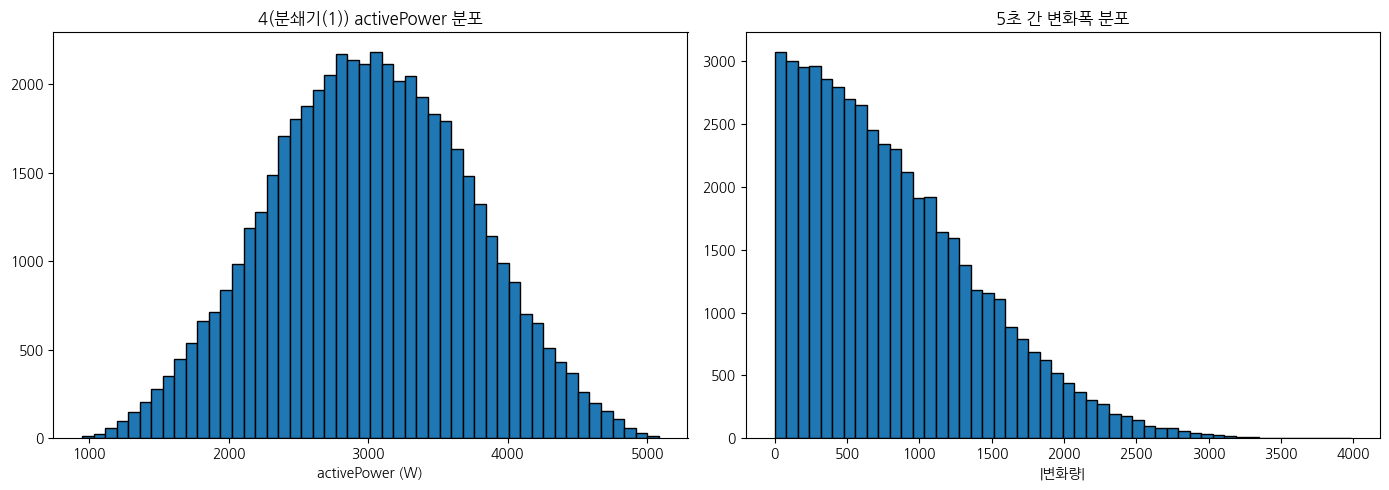

In [24]:
"""
패턴(진위 여부) 확인 스크립트
================================
1. 자기상관(lag-1) - 실제 물리 신호라면 이전 값과 다음 값이 어느 정도 비슷해야 함
2. 히스토그램 - 자연스러운 분포인지, 인위적으로 균일한 분포인지
3. step change 비율 - 값이 한 스텝(5초)만에 극단적으로 튀는 비율
"""

import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Nanum Gothic'
mpl.rcParams['axes.unicode_minus'] = False

import os
from dotenv import load_dotenv

load_dotenv()  # .env 파일 읽어서 환경변수로 등록

DB_CONFIG = dict(
    host=os.environ["DB_HOST"],
    user=os.environ["DB_USER"],
    password=os.environ["DB_PASSWORD"],
    database=os.environ["DB_NAME"],
)
TABLE_NAME = "raw_power_data"
MODULE = "4(분쇄기(1))"

conn = pymysql.connect(**DB_CONFIG)
df = pd.read_sql(
    f"SELECT ts, activePower FROM {TABLE_NAME} WHERE module = %s ORDER BY ts LIMIT 50000",
    conn, params=(MODULE,)
)
conn.close()

# =========================================================
# 1. 자기상관 (lag-1, lag-5, lag-30초 상당)
# =========================================================
print("=== 자기상관 (activePower) ===")
for lag in [1, 5, 10, 60]:  # 5초 간격 기준 -> 5초/25초/50초/5분 정도
    ac = df["activePower"].autocorr(lag=lag)
    print(f"  lag={lag} (약 {lag*5}초 전과 비교): {ac:.4f}")
print("  -> 실제 물리 신호면 lag=1에서 보통 0.7~0.99 수준으로 높게 나옴")
print("  -> 0에 가까우면 매 순간이 이전과 무관한 노이즈라는 뜻")

# =========================================================
# 2. 연속 두 값의 변화폭(step change) 분포
# =========================================================
df["step_change"] = df["activePower"].diff().abs()
print("\n=== 5초 사이 변화폭(|P(t)-P(t-1)|) 통계 ===")
print(df["step_change"].describe())
print(f"\n변화폭이 전체 범위(최대-최소)의 30% 이상인 비율: "
      f"{(df['step_change'] > (df['activePower'].max()-df['activePower'].min())*0.3).mean()*100:.2f}%")

# =========================================================
# 3. 히스토그램
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["activePower"], bins=50, edgecolor="black")
axes[0].set_title(f"{MODULE} activePower 분포")
axes[0].set_xlabel("activePower (W)")

axes[1].hist(df["step_change"].dropna(), bins=50, edgecolor="black")
axes[1].set_title("5초 간 변화폭 분포")
axes[1].set_xlabel("|변화량|")

plt.tight_layout()
plt.savefig("pattern_check_histogram.png", dpi=150)
print("\n저장 완료: pattern_check_histogram.png")